In [2]:
import torch
import neural_utils as nu

model = nu.FCN(1,1,4,2)

for i, p in enumerate(model.parameters()):
    print(f"Parameter {i}")
    print("shape:", p.shape)
    print(p)
    print()


Parameter 0
shape: torch.Size([4, 1])
Parameter containing:
tensor([[-0.0597],
        [-0.6625],
        [-0.3793],
        [ 0.9605]], requires_grad=True)

Parameter 1
shape: torch.Size([4])
Parameter containing:
tensor([-0.4045, -0.4786,  0.7140, -0.2548], requires_grad=True)

Parameter 2
shape: torch.Size([4, 4])
Parameter containing:
tensor([[ 0.0651,  0.1232, -0.0902, -0.4664],
        [ 0.3254, -0.0333,  0.1565, -0.3666],
        [-0.4873,  0.3573,  0.3793, -0.3217],
        [ 0.1415,  0.1639,  0.3382, -0.2620]], requires_grad=True)

Parameter 3
shape: torch.Size([4])
Parameter containing:
tensor([-0.1980, -0.1092,  0.2347,  0.3521], requires_grad=True)

Parameter 4
shape: torch.Size([1, 4])
Parameter containing:
tensor([[-0.1164,  0.1852, -0.3610,  0.2246]], requires_grad=True)

Parameter 5
shape: torch.Size([1])
Parameter containing:
tensor([-0.3655], requires_grad=True)



In [3]:
print(model.state_dict())

OrderedDict({'net.0.weight': tensor([[-0.0597],
        [-0.6625],
        [-0.3793],
        [ 0.9605]]), 'net.0.bias': tensor([-0.4045, -0.4786,  0.7140, -0.2548]), 'net.2.weight': tensor([[ 0.0651,  0.1232, -0.0902, -0.4664],
        [ 0.3254, -0.0333,  0.1565, -0.3666],
        [-0.4873,  0.3573,  0.3793, -0.3217],
        [ 0.1415,  0.1639,  0.3382, -0.2620]]), 'net.2.bias': tensor([-0.1980, -0.1092,  0.2347,  0.3521]), 'net.4.weight': tensor([[-0.1164,  0.1852, -0.3610,  0.2246]]), 'net.4.bias': tensor([-0.3655])})


In [19]:
import loss_landscape as ll
from importlib import reload 

reload(ll)


direction = ll.create_random_direction(model, dir_type='weights', norm='filter', ignore=['bias'])

for param, dir in zip(model.parameters(), direction[0]):
    print(param)
    print(param.data)
    print(param.data.shape == dir.shape)

Parameter containing:
tensor([[-0.0597],
        [-0.6625],
        [-0.3793],
        [ 0.9605]], requires_grad=True)
tensor([[-0.0597],
        [-0.6625],
        [-0.3793],
        [ 0.9605]])
True
Parameter containing:
tensor([-0.4045, -0.4786,  0.7140, -0.2548], requires_grad=True)
tensor([-0.4045, -0.4786,  0.7140, -0.2548])
True
Parameter containing:
tensor([[ 0.0651,  0.1232, -0.0902, -0.4664],
        [ 0.3254, -0.0333,  0.1565, -0.3666],
        [-0.4873,  0.3573,  0.3793, -0.3217],
        [ 0.1415,  0.1639,  0.3382, -0.2620]], requires_grad=True)
tensor([[ 0.0651,  0.1232, -0.0902, -0.4664],
        [ 0.3254, -0.0333,  0.1565, -0.3666],
        [-0.4873,  0.3573,  0.3793, -0.3217],
        [ 0.1415,  0.1639,  0.3382, -0.2620]])
True
Parameter containing:
tensor([-0.1980, -0.1092,  0.2347,  0.3521], requires_grad=True)
tensor([-0.1980, -0.1092,  0.2347,  0.3521])
True
Parameter containing:
tensor([[-0.1164,  0.1852, -0.3610,  0.2246]], requires_grad=True)
tensor([[-0.1164,  

In [60]:
from importlib import reload
reload(ll)

<module 'loss_landscape' from 'c:\\Users\\victo\\OneDrive\\Documents\\GitHub\\DiffEqML\\loss_landscape.py'>

In [52]:
weights = ll.get_weights(model)
print(weights)
direction = ll.create_random_direction(model, norm='filter', ignore=['bias'])
def f(a,b,c):
    return torch.zeros_like(a)
X,Y,losses = ll.compute(model, weights, direction, (-1,1,2) ,(-1,1,2), X_data=torch.tensor([1], dtype=torch.float32), U_data=torch.tensor([0], dtype=torch.float32), X_col=torch.tensor([1], dtype=torch.float32), f=f, lambda_phys=1)

print(X)
print(Y)
print(losses)

[tensor([[ 1.3047e+02],
        [ 3.9122e+04],
        [-3.0720e+01],
        [ 2.3341e+02]]), tensor([-5804378., -6867258., 10245616., -3655790.]), tensor([[ 51465.5391,  10645.2578, -41958.6172,  26536.1406],
        [-28380.7891,   1983.8115, -42443.9141, -25700.6289],
        [   934.3746,  -3218.9863,  -2585.9673,     62.2246],
        [  -487.9964,   -301.6643,    129.2198,   -173.5936]]), tensor([-2840522.5000, -1567449.0000,  3367603.5000,  5052883.0000]), tensor([[ -2203.8074, -60534.8984, -44184.6953,  18309.3516]]), tensor([-5244168.5000])]
[[-1. -1.]
 [ 1.  1.]]
[[-1.  1.]
 [-1.  1.]]
[[2.66701908e+13 2.72631018e+13]
 [2.69693475e+13 2.47704437e+14]]


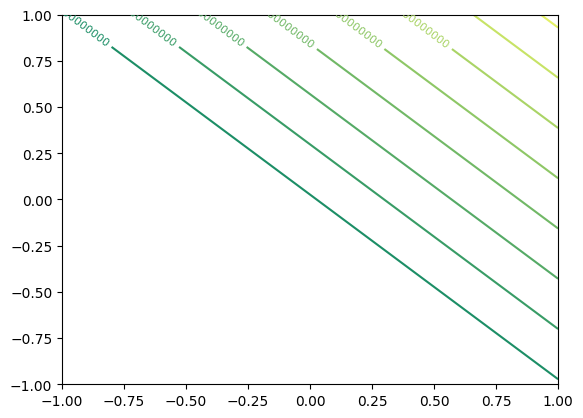

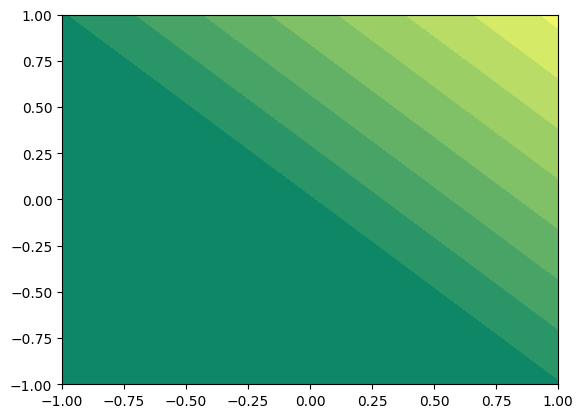

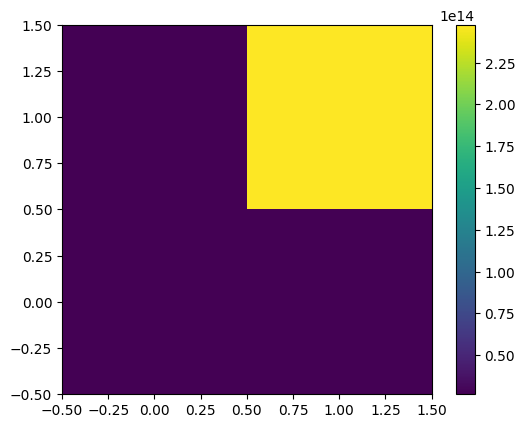

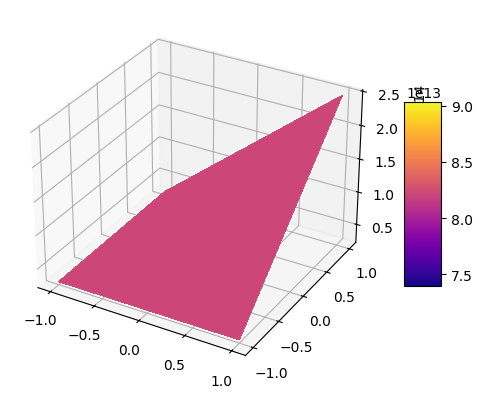

In [61]:
plot = ll.plot(X, Y, losses, name = "test")